In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.backend import BackendPolicy, backend
from src.layers import Conv1D, Dense
from src.layers.activation import Flatten, ReLU, Softmax, Tanh,ELU, LeakyReLU
from src.loss.cross_entropy import CrossEntropy
from src.models.neural_network import Network
from src.models.sequential import Sequential
from src.optimizer.adam import Adam



In [2]:
def prepare_har_dataset(csv_path: str) -> tuple[np.ndarray, np.ndarray, np.ndarray, int]:
    raw_data = np.genfromtxt(csv_path, delimiter=",")
    Y = raw_data[:, 9000].astype("int32")
    features_raw = raw_data[:, :9000].astype("float32")
    lengths = raw_data[:, 9001]

    num_samples = features_raw.shape[0]
    num_channels = 6
    time_steps = 1500
    X = np.zeros((num_samples, time_steps, num_channels), dtype="float32")
    for i in range(num_channels):
        X[:, :, i] = features_raw[:, i*1500 : (i+1)*1500]
    mask = np.arange(time_steps) < lengths[:, None]
    active_data = X[mask]
    scaler = StandardScaler()
    # scaler.fit(active_data)
    X_flat = X.reshape(-1, num_channels)
    # X_scaled_flat = scaler.transform(X_flat)
    X_final = X_flat.reshape(num_samples, time_steps, num_channels)
    X_final[~mask] = 0.0
    X_final = np.transpose(X_final, (0, 2, 1))
    return X_final, Y, lengths, X_final.nbytes + Y.nbytes



In [3]:
dataset_path = r"data\KU-HAR_v1.0_raw_samples.csv"
num_classes = 18
activity_map = {
    0: "Stand", 1: "Sit", 2: "Talk-sit", 3: "Talk-stand", 4: "Stand-sit",
    5: "Lay", 6: "Lay-stand", 7: "Pick", 8: "Jump", 9: "Push-up",
    10: "Sit-up", 11: "Walk", 12: "Walk-backward", 13: "Walk-circle",
    14: "Run", 15: "Stair-up", 16: "Stair-down", 17: "Table-tennis"
}


In [4]:

X,Y, lengths, total_bytes = prepare_har_dataset(dataset_path)
Y = np.eye(num_classes)[Y]

In [5]:
X_train, X_test, Y_train, Y_test, lengths_train, lengths_test = train_test_split(X, Y, lengths, test_size=0.2, random_state=2)


In [ ]:
from src.layers.activation.dropout import Dropout
from src.layers.global_concat_pool import GlobalConcatPool1D
from src.layers.masked_global_average import MaskedGlobalAveragePool1D


backend.configure(policy=BackendPolicy(use_gpu=True), dataset_bytes=total_bytes)
learning_rate = 1e-03
optimizer = Adam(learning_rate=learning_rate)
loss_fn = CrossEntropy()
model = Sequential([
    Conv1D(filters=32, kernel_size=15, stride=2, padding=7, name="conv1"),
    LeakyReLU(),
    Conv1D(filters=64, kernel_size=7, stride=2, padding=6, name="conv2"),
    LeakyReLU(),
    Conv1D(filters=128, kernel_size=3, stride=1, padding=1, name="conv2"),
    ELU(),
    GlobalConcatPool1D(name="masked_gap"),
    Dense(128),
    ELU(),
    Dropout(0.4),
    Dense(18),
    Softmax()
])
model.compile(optimizer=optimizer, loss=loss_fn)
history, total_time = model.fit(X_train, Y_train, epochs=250,batch_size=1024, verbose=5, mask=lengths_train, lr_decay_epochs=50, lr_decay=0.7)

2026-03-21 16:58:40,781 | INFO | src.backend | GPU requested. Dataset size: 330696740 bytes. Minimum for GPU: 8000000 bytes.
2026-03-21 16:58:40,782 | INFO | src.backend | CuPy available: True.
2026-03-21 16:58:40,782 | INFO | src.backend | Using backend: cupy
Epoch 1/250 - Loss: 6.346103 - 4.63s/epoch - ETA: 00:19:13
Epoch 6/250 - Loss: 1.614379 - 4.46s/epoch - ETA: 00:18:24
Epoch 11/250 - Loss: 0.790548 - 4.48s/epoch - ETA: 00:17:55
Epoch 16/250 - Loss: 0.558892 - 4.49s/epoch - ETA: 00:17:31
Epoch 21/250 - Loss: 0.456426 - 4.53s/epoch - ETA: 00:17:08
Epoch 26/250 - Loss: 0.389500 - 4.50s/epoch - ETA: 00:16:48
Epoch 31/250 - Loss: 0.353413 - 4.45s/epoch - ETA: 00:16:24
Epoch 36/250 - Loss: 0.319427 - 4.48s/epoch - ETA: 00:16:01
Epoch 41/250 - Loss: 0.296496 - 4.47s/epoch - ETA: 00:15:38
Epoch 46/250 - Loss: 0.267840 - 4.47s/epoch - ETA: 00:15:15
Epoch 50: Learning rate decayed to 0.000700
Epoch 51/250 - Loss: 0.245329 - 4.48s/epoch - ETA: 00:14:52
Epoch 56/250 - Loss: 0.227487 - 4.47s

In [ ]:
model.save('har_model_v1.nnp')

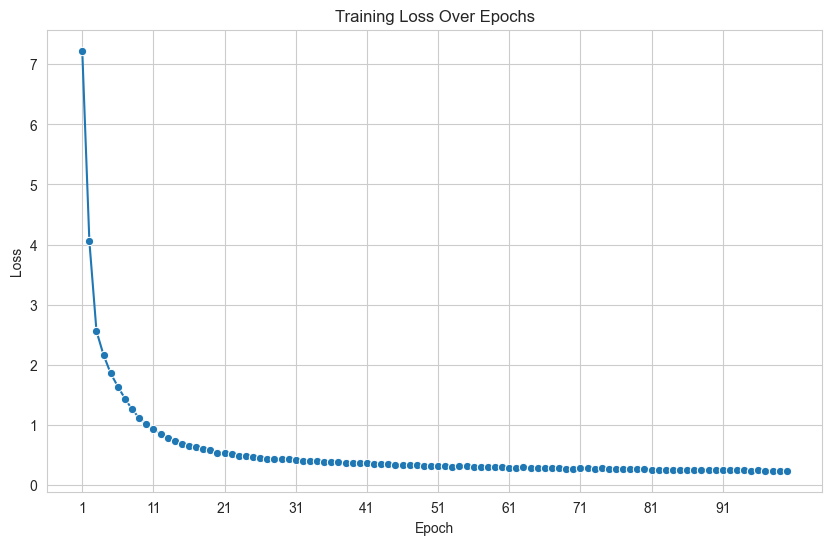

In [8]:
def plot_training_history(history, title="Training Loss Over Epochs"):
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=range(1, len(history) + 1), y=history, marker="o")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(range(1, len(history) + 1, max(1, len(history) // 10)))
    plt.show()

plot_training_history(history)

Test Accuracy: 0.9254
Test F1 Score: 0.9257
Classification Report:
               precision    recall  f1-score   support

        Stand       0.81      0.72      0.76       117
          Sit       0.61      0.82      0.70       101
     Talk-sit       0.90      0.89      0.89       132
   Talk-stand       0.98      1.00      0.99       112
    Stand-sit       1.00      1.00      1.00       183
          Lay       0.71      0.61      0.66       115
    Lay-stand       1.00      0.98      0.99       108
         Pick       0.96      1.00      0.98       108
         Jump       1.00      0.96      0.98        99
      Push-up       0.99      0.99      0.99       105
       Sit-up       1.00      0.98      0.99        89
         Walk       0.93      0.98      0.96       109
Walk-backward       0.96      1.00      0.98        46
  Walk-circle       1.00      0.86      0.92        35
          Run       0.99      0.98      0.99       117
     Stair-up       0.99      0.97      0.98        

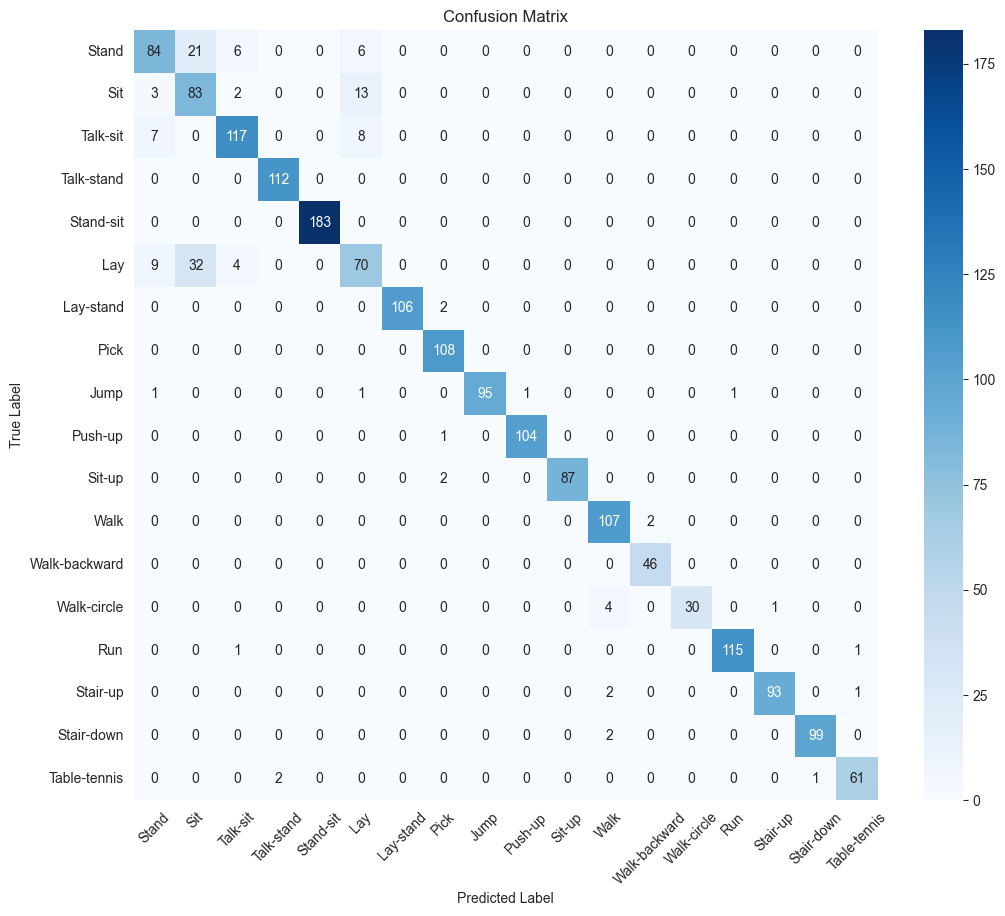

In [9]:
predictions = model.predict(X_test, mask=lengths_test)
y_true = np.argmax(Y_test, axis=1)
y_pred = np.argmax(predictions, axis=1)
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=[activity_map[i] for i in range(num_classes)]))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[activity_map[i] for i in range(num_classes)], yticklabels=[activity_map[i] for i in range(num_classes)])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:

def compare_gpu_vs_cpu(X, Y, model: Network, epochs=1, batch_size=64, verbose=5):
    if not backend._cupy_runtime_ok:
        print("GPU runtime not available. Skipping GPU vs CPU comparison.")
        return -1,-1
    backend.configure(policy=BackendPolicy(use_gpu=False), dataset_bytes=0)
    model.reset()
    X_cpu, Y_cpu = backend.asarray(X), backend.asarray(Y)
    _, cpu_time = model.fit(X_cpu, Y_cpu, epochs=epochs, batch_size=batch_size, verbose=verbose)
    model.reset()
    backend.configure(policy=BackendPolicy(use_gpu=True, min_gpu_bytes=0), dataset_bytes=10)
    X_gpu, Y_gpu = backend.asarray(X), backend.asarray(Y)
    _, gpu_time = model.fit(X_gpu, Y_gpu, epochs=epochs, batch_size=batch_size, verbose=verbose)
    return cpu_time, gpu_time

cpu_time, gpu_time = compare_gpu_vs_cpu(X, Y, model, epochs=25, batch_size=1024, verbose=5)
print(f"CPU time: {cpu_time:.2f} seconds")
print(f"GPU time: {gpu_time:.2f} seconds")
print(f"Speedup: {cpu_time / gpu_time:.2f}x")



2026-03-21 16:21:52,248 | INFO | src.backend | Using backend: numpy
Epoch 1/25 - Loss: 3.031899 - 5.36s/epoch - ETA: 00:02:08


KeyboardInterrupt: 